In [ ]:
## Benchmark Forecasting

# We evaluate benchmark models separately for each store.
# Each store uses its own history to create 42-day forecasts, and the metrics are stored per store and per model.
#Benchmark model: Mean,Naive,Drift,Seasonal Naive,AutoARIMA

In [10]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from pmdarima import auto_arima
except ImportError:
    auto_arima = None

# ==========================================================
# Load data
# ==========================================================
processed_dir = Path("data/processed")
if not processed_dir.exists():
    processed_dir = Path.cwd().parent / "data" / "processed"

sales = pd.read_csv(processed_dir / "sales_clean.csv")
sales["date"] = pd.to_datetime(sales["date"])
sales = sales.sort_values(["store_id", "date"])

# ==========================================================
# Helper functions
# ==========================================================

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def build_forecasts(train_series, test_len):
    forecasts = {}

    train_series = pd.Series(train_series).astype(float)
    train_series = train_series.replace([np.inf, -np.inf], np.nan).dropna()

    if len(train_series) < 10:
        return {
            "Mean": np.repeat(np.nan, test_len),
            "Naive": np.repeat(np.nan, test_len),
            "Drift": np.repeat(np.nan, test_len),
            "Seasonal Naive": np.repeat(np.nan, test_len),
            "AutoARIMA": np.repeat(np.nan, test_len),
        }

    forecasts["Mean"] = np.full(test_len, train_series.mean())
    forecasts["Naive"] = np.full(test_len, train_series.iloc[-1])

    drift = np.arange(1, test_len + 1)
    forecasts["Drift"] = train_series.iloc[-1] + drift * (
        (train_series.iloc[-1] - train_series.iloc[0]) / (len(train_series) - 1)
    )

    forecasts["Seasonal Naive"] = np.array([
        train_series.iloc[-7 + (i % 7)] for i in range(test_len)
    ])

    if auto_arima is not None:
        try:
            model = auto_arima(
                train_series,
                seasonal=True,
                m=7,
                stepwise=True,
                suppress_warnings=True,
                error_action="ignore",
            )
            forecasts["AutoARIMA"] = model.predict(n_periods=test_len)
        except Exception:
            forecasts["AutoARIMA"] = np.repeat(np.nan, test_len)
    else:
        forecasts["AutoARIMA"] = np.repeat(np.nan, test_len)

    return forecasts

# ==========================================================
# Train / test split by store
# ==========================================================
# We use all rows before the 42-day holdout period as training.
# The forecast origin is the day before the first test date, so no extra day is removed.

forecast_horizon = 42
results = []

for store_id, store_df in sales.groupby("store_id"):
    store_df = store_df.sort_values("date").copy()
    store_df["sales"] = pd.to_numeric(store_df["sales"], errors="coerce")
    store_df = store_df.dropna(subset=["sales"])

    if len(store_df) < forecast_horizon + 5:
        continue

    train_series = store_df.iloc[:-forecast_horizon]["sales"].astype(float)
    test_series = store_df.iloc[-forecast_horizon:]["sales"].astype(float)
    test_dates = store_df.iloc[-forecast_horizon:]["date"]

    forecasts = build_forecasts(train_series, forecast_horizon)

    for model_name, pred in forecasts.items():
        pred = np.asarray(pred, dtype=float)
        if np.isnan(pred).any():
            continue

        results.append({
            "store_id": store_id,
            "model": model_name,
            "mae": mae(test_series.values, pred),
            "mape": mape(test_series.values, pred),
            "forecast_dates": json.dumps([d.strftime("%Y-%m-%d") for d in test_dates]),
            "actual_values": json.dumps([float(v) for v in test_series.values]),
            "forecast_values": json.dumps([float(v) for v in pred]),
        })

results_df = pd.DataFrame(results)
print(results_df.head())
print(f"\nTotal rows: {len(results_df)}")

# ==========================================================
# Save results
# ==========================================================
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "benchmark_results_per_store.csv"
results_df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")

# ==========================================================
# Summary by model
# ==========================================================
summary_df = (
    results_df.groupby("model")[["mae", "mape"]]
    .mean()
    .sort_values("mae")
)
print(summary_df)


  store_id           model          mae        mape  \
0  store_1            Mean  1062.011176   12.494584   
1  store_1           Naive  3696.261905  100.000000   
2  store_1           Drift  3871.385628  103.971858   
3  store_1  Seasonal Naive  1383.833333   39.491304   
4  store_1       AutoARIMA  1039.439371   14.893060   

                                      forecast_dates  \
0  ["2015-06-08", "2015-06-09", "2015-06-10", "20...   
1  ["2015-06-08", "2015-06-09", "2015-06-10", "20...   
2  ["2015-06-08", "2015-06-09", "2015-06-10", "20...   
3  ["2015-06-08", "2015-06-09", "2015-06-10", "20...   
4  ["2015-06-08", "2015-06-09", "2015-06-10", "20...   

                                       actual_values  \
0  [4071.0, 4102.0, 3591.0, 3627.0, 3695.0, 4256....   
1  [4071.0, 4102.0, 3591.0, 3627.0, 3695.0, 4256....   
2  [4071.0, 4102.0, 3591.0, 3627.0, 3695.0, 4256....   
3  [4071.0, 4102.0, 3591.0, 3627.0, 3695.0, 4256....   
4  [4071.0, 4102.0, 3591.0, 3627.0, 3695.0, 4256....

In [2]:
# ==========================================================
# Mean & Median Accuracy by Model
# ==========================================================
from pathlib import Path
import pandas as pd

results_df = pd.read_csv(
    Path("data/processed") / "benchmark_results_per_store.csv"
)

summary_stats = (
    results_df
    .groupby("model")
    .agg(
        MAE_Mean=("mae", "mean"),
        MAE_Median=("mae", "median"),
        MAPE_Mean=("mape", "mean"),
        MAPE_Median=("mape", "median"),
    )
    .round(3)
    .sort_values("MAPE_Mean")
)

print("\n============================================================")
print("Mean and Median Accuracy by Model")
print("============================================================")
print(summary_stats)


Mean and Median Accuracy by Model
                MAE_Mean  MAE_Median  MAPE_Mean  MAPE_Median
model                                                       
Mean            2126.523    2039.056     20.748       19.939
AutoARIMA       2330.696    1744.770     31.556       21.150
Seasonal Naive  2146.890    2106.440     39.753       42.666
Naive           5795.228    5588.250     97.778      100.000
Drift           6025.591    5830.975    101.232      103.453


In [ ]:
# ==========================================================
# ETS Benchmark Forecasting
# ==========================================================
#Since autoarima takes a lot of time, we also make ETS to balance efficiency and accuracy
# This cell adds ETS results without rerunning AutoARIMA.
# It uses the same train/test split, metrics, and result format as the benchmark cell.

#Accordind to EDA STEP18, Exploratory analysis revealed a clear weekly seasonal pattern across the dataset. 
#Therefore, a seasonal period of seven days was adopted. 
#Although no strong global trend was observed after aggregation, individual stores may still exhibit local trends. 
#Hence, an additive trend component was retained and its suitability was validated through benchmark comparison.

from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_results = []

for store_id, store_df in sales.groupby("store_id"):
    store_df = store_df.sort_values("date").copy()
    store_df["sales"] = pd.to_numeric(store_df["sales"], errors="coerce")
    store_df = store_df.dropna(subset=["sales"])

    if len(store_df) < forecast_horizon + 14:
        continue

    train_series = store_df.iloc[:-forecast_horizon]["sales"].astype(float)
    test_series = store_df.iloc[-forecast_horizon:]["sales"].astype(float)
    test_dates = store_df.iloc[-forecast_horizon:]["date"]

    try:
        ets_model = ExponentialSmoothing(
            train_series,
            trend="add",
            seasonal="add",
            seasonal_periods=7,
            initialization_method="estimated"
        ).fit(optimized=True)

        pred = ets_model.forecast(forecast_horizon)
        pred = np.maximum(np.asarray(pred, dtype=float), 0)

    except Exception:
        continue

    ets_results.append({
        "store_id": store_id,
        "model": "ETS",
        "mae": mae(test_series.values, pred),
        "mape": mape(test_series.values, pred),
        "forecast_dates": json.dumps([d.strftime("%Y-%m-%d") for d in test_dates]),
        "actual_values": json.dumps([float(v) for v in test_series.values]),
        "forecast_values": json.dumps([float(v) for v in pred]),
    })

ets_results_df = pd.DataFrame(ets_results)

# Remove old ETS rows if this cell is rerun, then append the new ETS results
results_df = results_df[results_df["model"] != "ETS"].copy()
results_df = pd.concat([results_df, ets_results_df], ignore_index=True)

print(ets_results_df.head())
print(f"\nETS rows added: {len(ets_results_df)}")

# ==========================================================
# Save updated benchmark results
# ==========================================================
output_path = output_dir / "benchmark_results_per_store_with_ets.csv"
results_df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")

# ETS results for all stores
ets_results_df = pd.DataFrame(ets_results)

print(ets_results_df)
print(f"\nNumber of stores forecasted: {len(ets_results_df)}")

# Save ETS results only
ets_output = output_dir / "ets_results_per_store.csv"
ets_results_df.to_csv(ets_output, index=False)

print(f"Saved: {ets_output}")

    store_id model          mae       mape  \
0    store_1   ETS   510.298111  13.600065   
1   store_10   ETS  1065.707677  17.424163   
2  store_100   ETS   927.404271  15.861444   
3  store_101   ETS   728.609107  15.887730   
4  store_102   ETS  1268.910181  19.891188   

                                      forecast_dates  \
0  ["2015-06-08", "2015-06-09", "2015-06-10", "20...   
1  ["2015-06-08", "2015-06-09", "2015-06-10", "20...   
2  ["2015-06-08", "2015-06-09", "2015-06-10", "20...   
3  ["2015-06-08", "2015-06-09", "2015-06-10", "20...   
4  ["2015-06-08", "2015-06-09", "2015-06-10", "20...   

                                       actual_values  \
0  [4071.0, 4102.0, 3591.0, 3627.0, 3695.0, 4256....   
1  [6177.0, 5109.0, 5569.0, 5911.0, 5757.0, 5787....   
2  [5664.0, 5522.0, 5406.0, 4741.0, 4815.0, 6133....   
3  [5406.0, 5001.0, 4332.0, 4467.0, 4461.0, 3241....   
4  [6772.0, 6905.0, 6577.0, 6005.0, 5346.0, 5808....   

                                     forecast_val

In [ ]:
from pathlib import Path
import pandas as pd

# ============================================================
# File paths
# ============================================================

processed_dir = Path("data/processed")
raw_dir = Path("data/raw")

# ============================================================
# Load data
# ============================================================

results = pd.read_csv(processed_dir / "benchmark_results_per_store_with_ets.csv")
metadata = pd.read_csv(raw_dir / "metadata.csv")
# ============================================================
# Merge store type
# ============================================================

results = results.merge(
    metadata[["store_id", "store_type"]],
    on="store_id",
    how="left"
)

# ============================================================
# Average performance by Store Type and Model
# ============================================================

storetype_summary = (
    results
    .groupby(["store_type", "model"], as_index=False)
    .agg(
        Average_MAPE=("mape", "mean"),
        Average_MAE=("mae", "mean"),
        Number_of_Stores=("store_id", "nunique")
    )
)

# ============================================================
# Best model for each Store Type
# ============================================================

best_by_storetype = (
    storetype_summary
    .sort_values(["store_type", "Average_MAPE"])
    .groupby("store_type", as_index=False)
    .first()
)

# ============================================================
# Overall average performance
# ============================================================

overall_summary = (
    results
    .groupby("model", as_index=False)
    .agg(
        Average_MAPE=("mape", "mean"),
        Average_MAE=("mae", "mean"),
        Number_of_Stores=("store_id", "nunique")
    )
    .sort_values("Average_MAPE")
)

overall_best = overall_summary.head(1)

# ============================================================
# Print results
# ============================================================

print("=" * 60)
print("Best model for each Store Type")
print("=" * 60)
print(best_by_storetype)

print()

print("=" * 60)
print("Overall Best Model")
print("=" * 60)
print(overall_best)

# ============================================================
# Save results
# ============================================================

storetype_summary.to_csv(
    "average_performance_by_storetype.csv",
    index=False
)


overall_summary.to_csv(
    "overall_model_performance.csv",
    index=False
)



print("\nSaved:")
print("average_performance_by_storetype.csv")
print("overall_model_performance.csv")

# ============================================================
# ETS Mean & Median Accuracy
# ============================================================

ets_summary = (
    results[results["model"] == "ETS"]
    .groupby("model")[["mae", "mape"]]
    .agg(["mean", "median"])
    .round(3)
)

ets_summary.columns = [
    "MAE_Mean",
    "MAE_Median",
    "MAPE_Mean",
    "MAPE_Median",
]

print()
print("=" * 60)
print("ETS Accuracy Summary")
print("=" * 60)
print(ets_summary)


Best model for each Store Type
  store_type model  Average_MAPE  Average_MAE  Number_of_Stores
0          a   ETS     16.518481  1013.350507               377
1          b   ETS     11.933989  1339.722205                11
2          c   ETS     18.607097  1032.297718                75
3          d   ETS     17.772124  1074.388701               213

Overall Best Model
  model  Average_MAPE  Average_MAE  Number_of_Stores
2   ETS     17.070615  1039.995869               676

Saved:
average_performance_by_storetype.csv
overall_model_performance.csv

ETS Accuracy Summary
       MAE_Mean  MAE_Median  MAPE_Mean  MAPE_Median
model                                              
ETS    1039.996    1003.901     17.071       16.304


In [17]:
# ============================================================
# Validation: Winner Count by Store
# ============================================================

# Find the best model (lowest MAPE) for each store
best_model_each_store = (
    results
    .sort_values(["store_id", "mape"])
    .groupby("store_id", as_index=False)
    .first()
)

# Count how many stores each model wins
winner_summary = (
    best_model_each_store
    .groupby("model", as_index=False)
    .agg(
        Stores_Won=("store_id", "count")
    )
    .sort_values("Stores_Won", ascending=False)
)

# Percentage of stores won
winner_summary["Win_Rate (%)"] = (
    winner_summary["Stores_Won"] /
    winner_summary["Stores_Won"].sum() * 100
).round(2)

print()
print("=" * 60)
print("Validation: Best Model by Individual Store")
print("=" * 60)
print(winner_summary)




Validation: Best Model by Individual Store
            model  Stores_Won  Win_Rate (%)
1             ETS         449         66.42
2            Mean         135         19.97
0       AutoARIMA          88         13.02
3  Seasonal Naive           4          0.59


In [8]:
# ==========================================================
# ETS Final Sales Forecast
# ==========================================================
# Train one ETS model for each store using the full historical
# dataset and forecast daily sales for the next 6 weeks.

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ==========================================================
# File paths
# ==========================================================

processed_dir = Path("data/processed")

if not processed_dir.exists():
    processed_dir = Path.cwd().parent / "data" / "processed"

sales_path = processed_dir / "sales_clean.csv"
output_path = processed_dir / "ETS Result.csv"

# ==========================================================
# Load data
# ==========================================================

sales = pd.read_csv(sales_path)

sales["date"] = pd.to_datetime(sales["date"])
sales["sales"] = pd.to_numeric(sales["sales"], errors="coerce")

sales = (
    sales
    .dropna(subset=["store_id", "date", "sales"])
    .sort_values(["store_id", "date"])
)

# ==========================================================
# ETS forecast for all stores
# ==========================================================

forecast_horizon = 42
ets_results = []

for store_id, store_df in sales.groupby("store_id"):

    store_df = store_df.sort_values("date")
    train_series = store_df["sales"].astype(float)

    if len(train_series) < 14:
        continue

    try:
        ets_model = ExponentialSmoothing(
            train_series,
            trend="add",
            seasonal="add",
            seasonal_periods=7,
            initialization_method="estimated"
        ).fit(optimized=True)

        forecast_values = ets_model.forecast(forecast_horizon)
        forecast_values = np.maximum(
            np.asarray(forecast_values, dtype=float),
            0
        )

        forecast_dates = pd.date_range(
            start=store_df["date"].max() + pd.Timedelta(days=1),
            periods=forecast_horizon,
            freq="D"
        )

        for forecast_date, forecast_sales in zip(
            forecast_dates,
            forecast_values
        ):
            ets_results.append({
                "store_id": store_id,
                "date": forecast_date,
                "sales": float(forecast_sales)
            })

    except Exception as error:
        print(f"ETS failed for {store_id}: {error}")

# ==========================================================
# Save forecast results
# ==========================================================

ets_result_df = pd.DataFrame(ets_results)

if ets_result_df.empty:
    raise RuntimeError("ETS did not produce forecasts for any store.")

ets_result_df = ets_result_df.sort_values(
    ["store_id", "date"]
).reset_index(drop=True)

ets_result_df.to_csv(
    output_path,
    index=False,
    date_format="%Y-%m-%d"
)

# ==========================================================
# Total sales result
# ==========================================================

number_of_stores = ets_result_df["store_id"].nunique()
total_sales_result = ets_result_df["sales"].sum()

print("=" * 60)
print("ETS Final Forecast")
print("=" * 60)
print(f"Stores forecasted     : {number_of_stores}")
print(f"Forecast days         : {forecast_horizon}")
print(f"Total forecast rows   : {len(ets_result_df)}")
print(f"Total sales result    : {total_sales_result:,.2f}")
print(f"Saved                 : {output_path}")

ETS Final Forecast
Stores forecasted     : 676
Forecast days         : 42
Total forecast rows   : 28392
Total sales result    : 173,830,086.84
Saved                 : data\processed\ETS Result.csv


Weekly Forecast by Store Type
   store_type  week  Predicted_Weekly_Sales
0           a     1            1.594876e+07
1           a     2            1.597190e+07
2           a     3            1.599518e+07
3           a     4            1.601845e+07
4           a     5            1.604179e+07
5           a     6            1.606518e+07
6           b     1            9.745738e+05
7           b     2            9.792858e+05
8           b     3            9.839978e+05
9           b     4            9.887098e+05
10          b     5            9.934219e+05
11          b     6            9.981339e+05
12          c     1            2.995822e+06
13          c     2            3.001962e+06
14          c     3            3.008104e+06
15          c     4            3.014288e+06
16          c     5            3.020543e+06
17          c     6            3.026842e+06
18          d     1            8.915400e+06
19          d     2            8.936056e+06
20          d     3            8.956770e+06
21

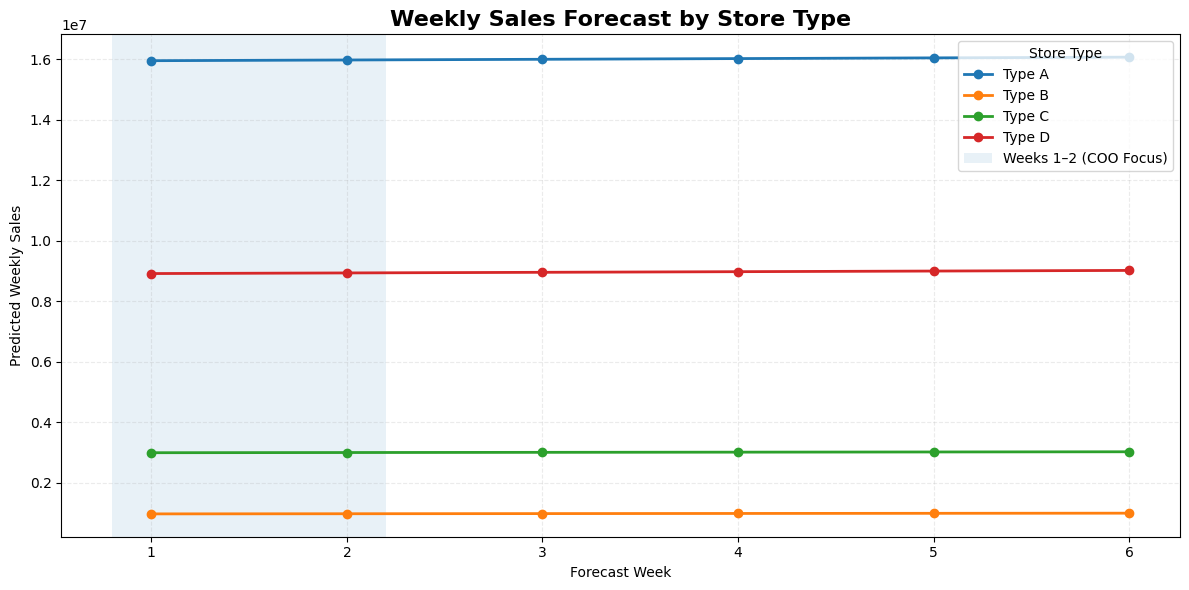


Saved:
data\processed\ETS Forecast by Store Type.csv
data\processed\Weekly Sales Forecast by Store Type.png


In [ ]:
# ==========================================================
# Final Forecast Analysis by Store Type
# ==========================================================
# Merge the final ETS forecasts with store metadata and
# aggregate predicted sales into six consecutive forecast weeks.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# File paths
# ==========================================================

processed_dir = Path("data/processed")
raw_dir = Path("data/raw")

if not processed_dir.exists():
    processed_dir = Path.cwd().parent / "data" / "processed"

if not raw_dir.exists():
    raw_dir = Path.cwd().parent / "data" / "raw"

forecast_path = processed_dir / "ETS Result.csv"
metadata_path = raw_dir / "metadata.csv"
summary_path = processed_dir / "ETS Forecast by Store Type.csv"
figure_path = processed_dir / "Weekly Sales Forecast by Store Type.png"

# ==========================================================
# Load and merge data
# ==========================================================

forecast = pd.read_csv(forecast_path)
metadata = pd.read_csv(metadata_path)

forecast["date"] = pd.to_datetime(forecast["date"])
forecast["sales"] = pd.to_numeric(
    forecast["sales"],
    errors="coerce"
)

forecast = forecast.merge(
    metadata[["store_id", "store_type"]],
    on="store_id",
    how="left"
)

if forecast["store_type"].isna().any():
    raise ValueError("Some forecast stores have no matching store type.")

# ==========================================================
# Assign forecast weeks
# ==========================================================

forecast_start = forecast["date"].min()

forecast["week"] = (
    (forecast["date"] - forecast_start).dt.days // 7 + 1
)

# ==========================================================
# Weekly sales by Store Type
# ==========================================================

weekly_storetype = (
    forecast
    .groupby(["store_type", "week"], as_index=False)
    .agg(
        Predicted_Weekly_Sales=("sales", "sum")
    )
    .sort_values(["store_type", "week"])
)

weekly_storetype.to_csv(
    summary_path,
    index=False
)

# ==========================================================
# 6 week total by Store Type
# ==========================================================

six_week_summary = (
    weekly_storetype
    .groupby("store_type", as_index=False)
    .agg(
        Six_Week_Total=("Predicted_Weekly_Sales", "sum")
    )
    .sort_values("Six_Week_Total", ascending=False)
)

print("=" * 60)
print("Weekly Forecast by Store Type")
print("=" * 60)
print(weekly_storetype)

print()
print("=" * 60)
print("Six-Week Forecast Total by Store Type")
print("=" * 60)
print(six_week_summary)

print()
print(f"Overall six-week sales: {forecast['sales'].sum():,.2f}")

# ==========================================================
# Plot weekly sales forecast
# ==========================================================

plt.figure(figsize=(12, 6))

for store_type, type_data in weekly_storetype.groupby("store_type"):
    plt.plot(
        type_data["week"],
        type_data["Predicted_Weekly_Sales"],
        marker="o",
        linewidth=2,
        label=f"Type {store_type.upper()}"
    )

# Highlight the COO focus period
plt.axvspan(
    0.8,
    2.2,
    alpha=0.10,
    label="Weeks 1–2 (COO Focus)"
)

plt.title(
    "Weekly Sales Forecast by Store Type",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Forecast Week")
plt.ylabel("Predicted Weekly Sales")
plt.xticks(range(1, 7))
plt.grid(alpha=0.25, linestyle="--")
plt.legend(title="Store Type")
plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("Saved:")
print(summary_path)
print(figure_path)